# Winsorization 

Winsorization is a data preprocessing technique in machine learning used to reduce the effect of extreme values (outliers) without removing any data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('weight-height.csv')

df.sample(5)

,Gender,Height,Weight
7327,Female,61.968294,132.765642
1201,Male,67.992114,172.515530
9936,Female,64.780420,137.922681
6778,Female,65.176947,145.339906
669,Male,66.455602,188.974847


In [3]:
df.shape

(10000, 3)

In [4]:
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

findfont: Failed to find font weight normal, now using 700.


Text(0.5, 1.0, 'Height Distribution')

findfont: Failed to find font weight normal, now using 700.


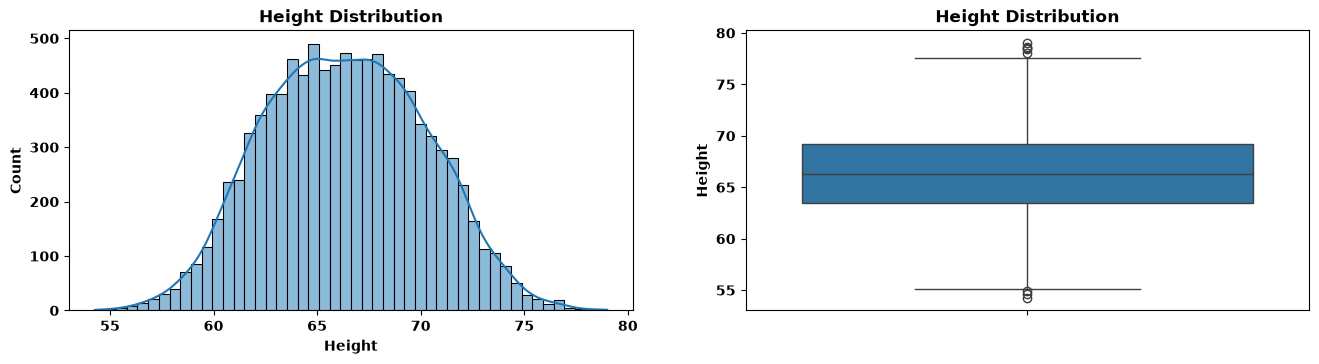

In [5]:
plt.figure(figsize=(16, 8))

plt.subplot(2, 2, 1)
sns.histplot(df['Height'], kde=True)
plt.title('Height Distribution')

plt.subplot(2, 2, 2)
sns.boxplot(df['Height'])
plt.title('Height Distribution')

In [6]:
upper_limit = df['Height'].quantile(0.99)
lower_limit = df['Height'].quantile(0.01)

print("Upper Limit: ", upper_limit)
print("Lower Limit: ", lower_limit)

Upper Limit:  74.7857900583366
Lower Limit:  58.13441158671655


In [10]:
# Trimming 

new_df = df[(df['Height'] <= 74.78) & (df['Height'] >= 58.13)]
new_df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [11]:
new_df['Height'].describe()

count    9799.000000
mean       66.363507
std         3.644267
min        58.134496
25%        63.577147
50%        66.317899
75%        69.119859
max        74.767447
Name: Height, dtype: float64

<Axes: ylabel='Height'>

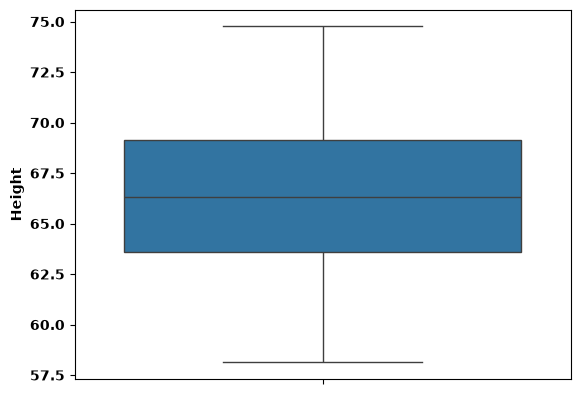

In [12]:
sns.boxplot(new_df['Height'])

<Axes: xlabel='Height', ylabel='Count'>

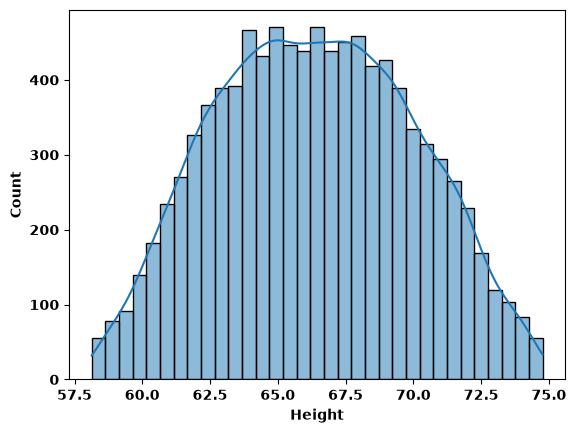

In [18]:
sns.histplot(new_df['Height'], kde=True)

In [13]:
# Capping --> Winsorization
new_df2 = df.copy()
new_df2['Height'] = np.where(
    new_df2['Height'] >= upper_limit,
    upper_limit,
    np.where(
        new_df2['Height'] <= lower_limit,
        lower_limit,
        new_df2['Height']
    )
)


In [15]:
new_df2['Height'].describe()

count    10000.000000
mean        66.366281
std          3.795717
min         58.134412
25%         63.505620
50%         66.318070
75%         69.174262
max         74.785790
Name: Height, dtype: float64

<Axes: ylabel='Height'>

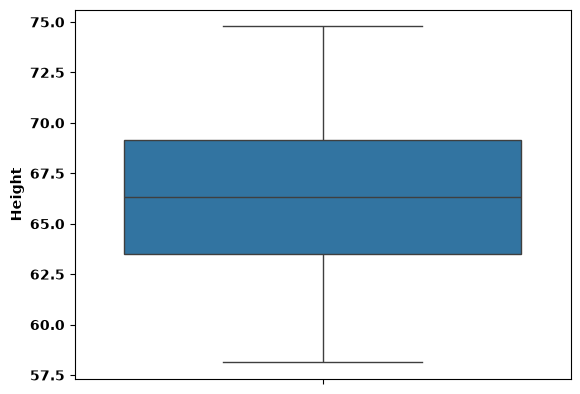

In [16]:
sns.boxplot(new_df2['Height'])

<Axes: xlabel='Height', ylabel='Count'>

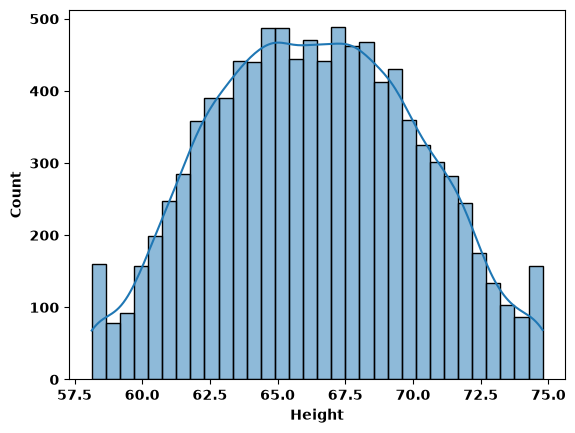

In [17]:
sns.histplot(new_df2['Height'], kde=True)